<div style="background: linear-gradient(120deg,#0f172a,#1e3a5f); border-radius:16px; padding:36px 40px; color:#e2e8f0;">
<h1 style="margin:0; font-size:2.1em; color:#ffffff;">⚡ RAG Foundations</h1>
<h3 style="margin:6px 0 0 0; font-weight:400; color:#93c5fd;">Session 1 of 4 — Why retrieval exists, and where it breaks</h3>
<p style="margin-top:18px; color:#cbd5e1;">NordWind Energy Workshop Series · Retrieval, Vectors & Graphs</p>
</div>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/noctetemp/nordwind-workshop/blob/main/session1_rag_foundations_en.ipynb)

## 🗺️ Today's journey

We climb a ladder. Each rung creates the *need* for the next one — by the end, RAG won't feel like a recipe someone handed you. It will feel **inevitable**.

* **🔤 Tokens** — what an LLM actually reads. Live demo: tokenize the same sentence in English and Japanese and compare the counts (spoiler: Japanese pays a token tax).
* **🧠 The context window** — the model's working memory. We measure the entire NordWind corpus in tokens against Claude's window — then scale up to a real company wiki and watch *that* overflow by 200×.
* **📉 Why not just make the window bigger?** — attention cost, and the *lost in the middle* problem. We hide a fact in a long context and watch recall wobble depending on **where** we hid it.
* **🎓 Why not fine-tuning?** — cost, staleness, no citations. A 5-minute honest discussion, no demo needed.
* **🔍 Therefore: retrieval** — we build a complete, naive RAG pipeline from scratch in ~40 lines. Chunk → embed → search → generate. And it *works*.
* **💥 The failure** — we ask our shiny new RAG system one specific question... and it faceplants. Understanding *why* is the door to Sessions 2, 3 and 4.

> **The world we'll live in for all four sessions:** *NordWind Energy* — a fictional power utility with 8 teams, 30 engineers, 15 services, 20 incidents, and 65 internal documents. Everything you build today gets reused, upgraded, and eventually turned into a knowledge graph.

## 0 · Setup

Two dependencies and one dataset. Run this and stretch while it installs (~1 min on Colab).

In [18]:
%pip -q install anthropic sentence-transformers tiktoken matplotlib
print("✅ Dependencies installed")

✅ Dependencies installed


In [19]:
# --- Download the NordWind dataset -------------------------------------
import json, urllib.request, pathlib

DATA_URL = "https://raw.githubusercontent.com/noctetemp/nordwind-workshop/main/dataset/documents.jsonl"
LOCAL = pathlib.Path("documents.jsonl")

if not LOCAL.exists():
    try:
        urllib.request.urlretrieve(DATA_URL, LOCAL)
    except Exception:
        print("⚠️ Could not download — upload documents.jsonl manually via the Files panel ⬅️")

docs = [json.loads(line) for line in LOCAL.read_text().splitlines()]
print(f"📚 Loaded {len(docs)} NordWind documents")
from collections import Counter
print(Counter(d['doc_type'] for d in docs))

📚 Loaded 65 NordWind documents
Counter({'postmortem': 20, 'runbook': 15, 'slack_thread': 12, 'adr': 10, 'overview': 8})


In [20]:
# --- Anthropic API key ---------------------------------------------------
# In Colab: click the 🔑 icon in the left sidebar → add secret ANTHROPIC_API_KEY
import os
try:
    from google.colab import userdata
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
    print("🔑 API key loaded from Colab secrets")
except Exception:
    print("⚠️ No Colab secret found — LLM cells will be skipped gracefully")

import anthropic
MODEL = "claude-sonnet-4-6"   # switch to a smaller model to reduce cost
client = anthropic.Anthropic() if os.environ.get("ANTHROPIC_API_KEY") else None

def ask_claude(prompt, system="You are a helpful assistant.", max_tokens=600):
    if client is None:
        return "[LLM skipped — no API key configured]"
    r = client.messages.create(model=MODEL, max_tokens=max_tokens,
                               system=system,
                               messages=[{"role": "user", "content": prompt}])
    return r.content[0].text

🔑 API key loaded from Colab secrets


Let's peek at one document so the corpus feels real before we start measuring it:

In [21]:
sample = next(d for d in docs if d['doc_id'] == 'PM-INC-2102')
print(sample['text'][:900])

# Postmortem INC-2102: Payment gateway timeout spike during evening peak

**Date:** 2025-08-05 · **Severity:** SEV1 · **Status:** Resolved
**Incident lead:** Roronoa Zoro (Payments & Billing)

The following is the incident review for INC-2102, payment gateway timeout spike during evening peak. It was compiled from the incident channel and on-call notes.

## Impact

The incident was visible to customers and triggered inbound support contacts. Time to detect was 6 minutes; time to mitigate was 95 minutes; full resolution took 147 minutes.

## Affected services

- **payment-gateway** (owned by Payments & Billing): processes card and bank payments with external PSPs
- **billing-engine** (owned by Payments & Billing): computes invoices from usage data and tariff plans

## Responders

- Roronoa Zoro (Payments & Billing) — incident lead
- Nico Robin (Payments & Billing) — responder
- Misato Kat


---
## 1 · 🔤 Tokens — what the model actually reads

LLMs don't read characters or words. They read **tokens** — chunks from a fixed vocabulary learned from training data. Everything about cost, speed, and memory is counted in tokens.

Frequent English words are usually 1 token. Rare words get split. And languages underrepresented in the tokenizer's training data pay a **token tax** — let's see it.

In [22]:
import tiktoken
# We use a well-known open tokenizer to demonstrate the concept.
# Every model family (Claude, GPT, Llama...) has its own tokenizer, but the behaviour is universal.
enc = tiktoken.get_encoding("cl100k_base")

pairs = [
    ("English",  "The payment gateway timed out during the evening peak."),
    ("Japanese", "決済ゲートウェイは夜間のピーク時にタイムアウトしました。"),
]
for lang, sentence in pairs:
    toks = enc.encode(sentence)
    print(f"{lang:9s} | {len(sentence):3d} chars → {len(toks):3d} tokens")
    pieces = [enc.decode_single_token_bytes(t) for t in toks[:14]]
    print("          |", [p.decode("utf-8", errors="replace") for p in pieces], "…\n")

# One kanji under the microscope: BPE tokenizers work on BYTES, not characters
kanji = "決"
print(f"'{kanji}' = 1 character = {len(kanji.encode('utf-8'))} bytes in UTF-8 = {len(enc.encode(kanji))} tokens")
print("raw bytes of each token:", [enc.decode_single_token_bytes(t) for t in enc.encode(kanji)])

English   |  54 chars →  10 tokens
          | ['The', ' payment', ' gateway', ' timed', ' out', ' during', ' the', ' evening', ' peak', '.'] …

Japanese  |  28 chars →  28 tokens
          | ['�', '�', '�', '�', '�', '�', 'ート', 'ウ', 'ェ', 'イ', 'は', '�', '�', '間'] …

'決' = 1 character = 3 bytes in UTF-8 = 2 tokens
raw bytes of each token: [b'\xe6\xb1', b'\xba']


**Those � symbols are not a bug — they are the lesson.** The tokenizer operates on UTF-8 *bytes*. A kanji like 決 occupies 3 bytes, and the tokenizer routinely splits it *mid-character* into two tokens; decoding either half alone yields invalid UTF-8, which your terminal renders as �. English words map to whole tokens — Japanese characters get sliced into byte fragments. *That* is the mechanical source of the token tax.

**Discussion point for the room:** the Japanese sentence says the same thing but costs roughly 2× the tokens. For a bilingual organisation, this affects context budgets, latency and cost — it's not academic trivia.

Now the question that drives this entire workshop: *how much can the model read at once?*

---
## 2 · 🧠 The context window — working memory, not knowledge

The **context window** is the maximum number of tokens the model can attend to in a single request — prompt *and* response combined. Think of it as working memory (a desk), not long-term knowledge (the library).

Claude's window is ~**200K tokens**. Sounds enormous. Let's measure our tiny fictional company against it.

NordWind corpus: 65 docs, 13,259 tokens


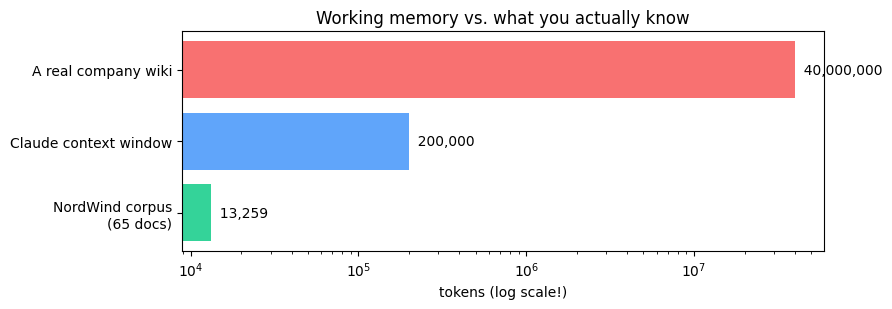

In [23]:
corpus_tokens = sum(len(enc.encode(d['text'])) for d in docs)
print(f"NordWind corpus: {len(docs)} docs, {corpus_tokens:,} tokens")

CLAUDE_WINDOW = 200_000
REAL_CONFLUENCE = 40_000_000   # a realistic internal wiki for a 150-engineer org

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 3.2))
bars = [("NordWind corpus\n(65 docs)", corpus_tokens, "#34d399"),
        ("Claude context window", CLAUDE_WINDOW, "#60a5fa"),
        ("A real company wiki", REAL_CONFLUENCE, "#f87171")]
ax.barh([b[0] for b in bars], [b[1] for b in bars], color=[b[2] for b in bars])
ax.set_xscale("log"); ax.set_xlabel("tokens (log scale!)")
for i, (_, v, _) in enumerate(bars):
    ax.text(v, i, f"  {v:,}", va="center")
ax.set_title("Working memory vs. what you actually know")
plt.tight_layout(); plt.show()

Read that chart carefully — the axis is **logarithmic**. Our toy corpus fits in the window (barely leaving room to think). A *real* knowledge base is **200× the window**. It does not fit. It will never fit.

(And yes — our *workshop* corpus is deliberately tiny so that 30 people can embed it in seconds on free Colab. The green bar could be stuffed into a single prompt today; we will confront that objection head-on at the end of the session. Every technique we build must be judged against the **red** bar, not the green one.)

So the naive plan — *"just paste everything into the prompt"* — is dead on arrival for real organisations. But wait, windows keep growing... why not just wait for a 40M-token window?

---
## 3 · 📉 Why "just make it bigger" doesn't save you

Two hard problems:

1. **Cost & latency scale with context.** Attention over N tokens costs O(N²) in the worst case — and you pay for every input token on *every single request*. Shipping 40M tokens to answer "when is the invoice due?" is like mailing the whole library to someone who asked for one quote.
2. **Lost in the middle.** Even when content fits, models recall information near the **start** and **end** of the context better than information buried in the **middle**. Retrieval quality degrades exactly where you can't see it.

Let's test #2 live on our own corpus: we hide one specific fact inside a big blob of NordWind documents — at the start, middle, and end — and ask Claude to find it.

In [24]:
# --- Needle in a haystack ------------------------------------------------
NEEDLE = ("INTERNAL MEMO: The NordWind disaster-recovery passphrase rotation "
          "is scheduled for the 14th of every month at 03:00 UTC.")
QUESTION = "When is the disaster-recovery passphrase rotation scheduled?"

haystack = "\n\n".join(d['text'] for d in docs if d['doc_type'] in ('runbook','overview','adr'))
print(f"Haystack size: {len(enc.encode(haystack)):,} tokens")

def hide_needle(position):
    if position == "start":  return NEEDLE + "\n\n" + haystack
    if position == "end":    return haystack + "\n\n" + NEEDLE
    half = len(haystack) // 2
    return haystack[:half] + "\n\n" + NEEDLE + "\n\n" + haystack[half:]

for pos in ["start", "middle", "end"]:
    context = hide_needle(pos)
    answer = ask_claude(
        f"Answer strictly from the documents below.\n\n<documents>\n{context}\n</documents>\n\nQuestion: {QUESTION}",
        max_tokens=100)
    print(f"[needle at {pos:6s}] → {answer.strip()[:140]}")

Haystack size: 4,314 tokens
[needle at start ] → Based on the internal memo in the documents, the NordWind disaster-recovery passphrase rotation is scheduled for the **14th of every month a
[needle at middle] → I'm not able to answer that question from the official engineering documentation. While a note about a "NordWind disaster-recovery passphras
[needle at end   ] → Based on the documents, the NordWind disaster-recovery passphrase rotation is scheduled for **the 14th of every month at 03:00 UTC**.


> 🎤 **Facilitator note:** modern models often *pass* this small test — that's fine, and say so honestly. The documented effect grows with context length and distractor density; the demo's job is to plant the intuition that **position and noise matter**, and that stuffing is a strategy you can't monitor. If it wobbles live: even better.

So: everything doesn't fit, and even when it fits, recall isn't uniform. What about baking knowledge into the weights instead?

---
## 4 · 🎓 Why not fine-tuning?

Fine-tuning changes the model's **weights**. It's the right tool for changing *behaviour* — tone, format, domain style. It's the wrong tool for injecting *facts*:

| | Fine-tuning | Retrieval |
|---|---|---|
| New document arrives | Retrain (hours, $$) | Index it (seconds) |
| "Where did that answer come from?" | 🤷 no provenance | Cites the exact chunk |
| Delete/correct a fact | Nearly impossible | Delete/update the chunk |
| Access control per user | No | Filter at query time |
| Hallucination on missing knowledge | Confidently wrong | Can say "not found" |

For **knowledge**, we want it *outside* the model, in a store we control — fetched at question time.

That word — *fetched* — is the whole idea. Welcome to **Retrieval-Augmented Generation**.

---
## 5 · 🔍 Building naive RAG from scratch

The pipeline, which we will refine for three more sessions:

```
 ingest → chunk → embed → index → RETRIEVE → augment prompt → generate
```

Today we build the simplest honest version:
- **Chunk**: split each document into overlapping windows
- **Embed**: turn each chunk into a vector with a local model (no API needed)
- **Index**: a plain numpy matrix 😄 (Session 2 explains why this breaks at scale)
- **Retrieve**: cosine similarity, top-k
- **Generate**: Claude answers *using only the retrieved chunks*

In [25]:
# --- Chunking ------------------------------------------------------------
def chunk_text(text, size=800, overlap=150):
    chunks, i = [], 0
    while i < len(text):
        chunks.append(text[i:i+size])
        i += size - overlap
    return chunks

chunks, meta = [], []
for d in docs:
    for j, ch in enumerate(chunk_text(d['text'])):
        chunks.append(ch)
        meta.append({"doc_id": d['doc_id'], "title": d['title'], "chunk": j})

print(f"{len(docs)} documents → {len(chunks)} chunks")

65 documents → 122 chunks


A number like "491 chunks" is abstract — let's look at one. A **chunk** is just a window of raw text, and consecutive chunks **overlap** so that a sentence cut at a boundary still appears whole in one of them:

In [39]:
print("═══ CHUNK 0 (the first 800 characters of the first postmortem) ═══\n")
print(chunks[0])
print("\n═══ THE OVERLAP ═══")
print("last 150 chars of chunk 0 == first 150 chars of chunk 1:", chunks[0][-150:] == chunks[0][:150])
print(f"\nEach chunk ≈ {len(chunks[0])} chars ≈ {len(enc.encode(chunks[0]))} tokens — small enough to point at one idea, big enough to carry its context. Chunk size is a real tuning knob (Session 2).")

═══ CHUNK 0 (the first 800 characters of the first postmortem) ═══

# Postmortem INC-2101: Billing run produced duplicate invoices

**Date:** 2025-07-16 · **Severity:** SEV2 · **Status:** Resolved
**Incident lead:** Nico Robin (Payments & Billing)

The following is the incident review for INC-2101, billing run produced duplicate invoices. It was compiled from the incident channel and on-call notes.

## Impact

A subset of customers and internal workflows were affected. Time to detect was 6 minutes; time to mitigate was 29 minutes; full resolution took 248 minutes.

## Affected services

- **billing-engine** (owned by Payments & Billing): computes invoices from usage data and tariff plans

## Responders

- Nico Robin (Payments & Billing) — incident lead
- Light Yagami (Payments & Billing) — responder
- Olivier Armstrong (Data Platform) — responder

## Timel

═══ THE OVERLAP ═══
last 150 chars of chunk 0 == first 150 chars of chunk 1: False

Each chunk ≈ 800 chars ≈ 185 tokens — small en

In [40]:
# find the first pair of consecutive chunks from the SAME document
for i in range(len(chunks) - 1):
    if meta[i]["doc_id"] == meta[i+1]["doc_id"]:
        break

print(f"Doc: {meta[i]['doc_id']} — chunks {meta[i]['chunk']} and {meta[i+1]['chunk']}\n")
print("END of chunk", i, "  →  …", repr(chunks[i][-150:]))
print()
print("START of chunk", i+1, "→ ", repr(chunks[i+1][:150]), "…")
print()
print("identical:", chunks[i][-150:] == chunks[i+1][:150])

Doc: PM-INC-2101 — chunks 0 and 1

END of chunk 0   →  … 'o Robin (Payments & Billing) — incident lead\n- Light Yagami (Payments & Billing) — responder\n- Olivier Armstrong (Data Platform) — responder\n\n## Timel'

START of chunk 1 →  'o Robin (Payments & Billing) — incident lead\n- Light Yagami (Payments & Billing) — responder\n- Olivier Armstrong (Data Platform) — responder\n\n## Timel' …

identical: True


In [30]:
# --- Embedding (local, free, no API key) ----------------------------------
from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer("all-MiniLM-L6-v2")   # 384 dimensions, ~90MB
E = embedder.encode(chunks, normalize_embeddings=True, show_progress_bar=True)
print("Embedding matrix:", E.shape)  # (n_chunks, 384)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding matrix: (122, 384)


In [31]:
# --- Retrieval: cosine similarity = dot product on normalized vectors -----
def retrieve(query, k=4):
    # 1. Embed the query into the SAME 384-dim space as the chunks
    q = embedder.encode([query], normalize_embeddings=True)
    # 2. The actual search is this ONE matrix multiplication:
    #    E is (n_chunks × 384), q.T is (384 × 1) → E @ q.T computes the
    #    dot product of the query against EVERY chunk at once. Normalized
    #    vectors ⇒ dot product == cosine similarity. This is brute-force kNN.
    scores = (E @ q.T).ravel()   # .ravel() merely flattens (n,1)→(n,) — NumPy housekeeping, no magic
    # 3. Rank: indices of the k highest scores
    top = np.argsort(-scores)[:k]
    return [(scores[i], meta[i], chunks[i]) for i in top]

for score, m, ch in retrieve("Why did payments time out in the evening?"):
    print(f"{score:.3f}  {m['doc_id']:12s} {m['title'][:60]}")

0.500  PM-INC-2102  Postmortem INC-2102: Payment gateway timeout spike during ev
0.496  PM-INC-2102  Postmortem INC-2102: Payment gateway timeout spike during ev
0.447  PM-INC-2113  Postmortem INC-2113: Payment settlement file rejected by ban
0.447  PM-INC-2101  Postmortem INC-2101: Billing run produced duplicate invoices


👀 Look at those hits — the retriever found the INC-2102 postmortem and the payment-gateway runbook from a *paraphrased* question that shares almost no keywords with the documents. That's semantic search. Now wire it into generation:

In [32]:
# --- The full RAG loop -----------------------------------------------------
def rag_answer(question, k=4, show_sources=True):
    hits = retrieve(question, k)
    context = "\n\n---\n\n".join(
        f"[Source: {m['doc_id']} — {m['title']}]\n{ch}" for _, m, ch in hits)
    answer = ask_claude(
        f"Answer using ONLY the sources below. Cite source ids. "
        f"If the sources are insufficient, say so.\n\n{context}\n\nQuestion: {question}")
    if show_sources:
        print("Retrieved:", ", ".join(m['doc_id'] for _, m, _ in hits), "\n")
    return answer

print(rag_answer("What was the root cause of the payment gateway timeouts, and what actions were taken?"))

Retrieved: PM-INC-2102, PM-INC-2102, PM-INC-2117, PM-INC-2117 

## Root Cause of Payment Gateway Timeouts

According to **[PM-INC-2102]**, the root cause was that the **HTTP connection pool to the external PSP was capped at 20 connections**. During the 19:00 evening payment peak, this limit became saturated, causing requests to queue up until they timed out.

## Actions Taken

The following action items were identified to address the issue **[PM-INC-2102]**:

1. **Raise the PSP connection pool** from 20 to **200 connections**, with queue rejection enabled *(owner: Roronoa Zoro)*
2. **Add pool saturation dashboards** to improve visibility and enable earlier detection *(owner: Roronoa Zoro)*

Additionally, it was noted that rollback procedures were up to date and were available as part of the response **[PM-INC-2102]**.


✅ **That's a working RAG system in ~40 lines.** It retrieves the right postmortem, answers grounded in it, and cites its source. For single-fact questions over unstructured text, this pattern is genuinely production-shaped (Session 2 adds the engineering that makes it robust).

Time to break it. 😈

---
## 6 · 💥 The question that breaks everything

Some questions aren't about *finding a passage*. They're about **connecting facts across documents**. Try this one — read it slowly, because answering it requires:

1. knowing which services **depend on** `payment-gateway` (that fact lives in an ADR and a service-catalog page)
2. finding all incidents that **affected those services** (scattered across 20 postmortems)
3. **aggregating** every responder from those postmortems into one list

No single chunk contains the answer. The answer *is a join*.

In [33]:
HARD_QUESTION = ("Which engineers have responded to incidents affecting services "
                 "that depend on payment-gateway? List all of them.")

print(rag_answer(HARD_QUESTION, k=6))

Retrieved: PM-INC-2102, PM-INC-2107, PM-INC-2117, PM-INC-2117, PM-INC-2102, PM-INC-2101 

Based on the sources, I need to identify incidents where **payment-gateway** was an affected service, then list all responders.

**INC-2102** — payment-gateway was affected [Source: PM-INC-2102]:
- Roronoa Zoro (incident lead)
- Nico Robin (responder)
- Misato Katsuragi (responder)

**INC-2117** — payment-gateway was affected [Source: PM-INC-2117]:
- Tanjiro Kamado (incident lead)
- Roronoa Zoro (responder)

---

**Complete list of engineers who responded to incidents affecting payment-gateway:**

1. **Roronoa Zoro** (Payments & Billing) — [PM-INC-2102, PM-INC-2117]
2. **Nico Robin** (Payments & Billing) — [PM-INC-2102]
3. **Misato Katsuragi** (Core Infrastructure) — [PM-INC-2102]
4. **Tanjiro Kamado** (Customer Platform) — [PM-INC-2117]


In [34]:
# --- Ground truth: don't trust me — COMPUTE it -------------------------------
# The NordWind world ships with its structure as data. Three set operations:
import urllib.request
RELS_URL = "https://raw.githubusercontent.com/noctetemp/nordwind-workshop/main/dataset/relationships.json"
rels = json.loads(urllib.request.urlopen(RELS_URL).read())
print(f"{len(rels)} typed relationships, e.g. {rels[40]}\n")

# hop 1: which services DEPEND ON payment-gateway?
dependents = {r["from"] for r in rels if r["type"] == "DEPENDS_ON" and r["to"] == "payment-gateway"}
# hop 2: which incidents AFFECTED those services?
incidents  = {r["from"] for r in rels if r["type"] == "AFFECTED"   and r["to"] in dependents}
# hop 3: which engineers RESPONDED TO those incidents?
engineers  = sorted({r["from"] for r in rels if r["type"] == "RESPONDED_TO" and r["to"] in incidents})

print("hop 1 — services depending on payment-gateway:", sorted(dependents))
print("hop 2 — incidents affecting those services:   ", sorted(incidents))
print(f"hop 3 — the complete correct answer, {len(engineers)} engineers:")
for name in engineers:
    print("   •", name)

153 typed relationships, e.g. {'type': 'OWNS', 'from': 'Data Platform', 'to': 'reporting-service'}

hop 1 — services depending on payment-gateway: ['billing-engine']
hop 2 — incidents affecting those services:    ['INC-2101', 'INC-2102', 'INC-2105', 'INC-2110', 'INC-2116', 'INC-2120']
hop 3 — the complete correct answer, 10 engineers:
   • Bulma
   • Kakashi Hatake
   • Light Yagami
   • Mikasa Ackerman
   • Misato Katsuragi
   • Nico Robin
   • Olivier Armstrong
   • Roronoa Zoro
   • Shinji Ikari
   • Winry Rockbell


Compare Claude's answer to the ground truth. Typically the RAG answer is **partial** (it found 2–3 postmortems and listed their responders), **unaware of what it's missing**, and — worst of all — **confident**.

This is not a prompt problem. It's not a model problem. Retrieval by *similarity* fetched chunks that *sound like* the question. But the question needed chunks *related by structure*: dependency edges, incident links, membership. **Semantic similarity is not relationship traversal.**

Write that sentence down. It's the thesis of this entire workshop.

And notice what *you* just did to verify the answer: three hops across **typed relationships** — depends-on, affected, responded-to. You wrote a graph traversal in three lines of Python without knowing it. Hold that thought until Session 3.

One catch: this worked because our fictional world ships with a clean `relationships.json`. **Real companies don't have that file.** The relationships are buried in prose — in the ADRs and postmortems you've been searching all session. Extracting structure out of unstructured text is exactly what GraphRAG does. That's Session 4.

### 🙋 "But wait — couldn't we just stuff all 65 docs into one prompt?"

The best objection in the room, and at 13K tokens the answer is: **yes, and it would probably work.** Try it below. Then look at the arithmetic: stuffing costs the full corpus on *every question*, retrieval costs a handful of chunks — and the real target isn't 13K tokens, it's the 40-million-token red bar from earlier, where stuffing is physically impossible and *lost in the middle* degrades whatever does fit. The structural lesson survives at every scale: **similarity search cannot do joins.** Stuffing hides that at toy scale; production scale exposes it.

In [35]:
# OPTIONAL — the honest objection, tested (uses ~14K input tokens, one API call)
full_context = "\n\n".join(d['text'] for d in docs)
stuffed = ask_claude(
    f"Answer using ONLY these documents.\n\n<documents>\n{full_context}\n</documents>\n\nQuestion: {HARD_QUESTION}",
    max_tokens=400)
print(stuffed)

avg_chunk = corpus_tokens // len(chunks)
print(f"\n--- the arithmetic ---")
print(f"stuffing:  ~{corpus_tokens:,} input tokens per question")
print(f"RAG (k=6): ~{6*avg_chunk:,} input tokens per question  (~{corpus_tokens//(6*avg_chunk)}× cheaper)")
print(f"at 40M-token scale: stuffing = impossible; retrieval = same cost as today")

I'll systematically identify incidents where **payment-gateway** was an affected service, then list all responders.

---

## Incidents Affecting payment-gateway

### INC-2102 — Payment gateway timeout spike during evening peak
**Affected services:** payment-gateway, billing-engine
**Responders:**
- Roronoa Zoro (incident lead)
- Nico Robin
- Misato Katsuragi

### INC-2113 — Payment settlement file rejected by bank
**Affected services:** payment-gateway
**Responders:**
- Roronoa Zoro (incident lead)
- Lelouch Lamperouge

### INC-2117 — Customer portal checkout errors for corporate accounts
**Affected services:** customer-portal, payment-gateway
**Responders:**
- Tanjiro Kamado (incident lead)
- Roronoa Zoro

---

## Complete List of Responders

1. **Roronoa Zoro** (Payments & Billing)
2. **Nico Robin** (Payments & Billing)
3. **Misato Katsuragi** (Core Infrastructure)
4. **Lelouch Lamperouge** (Security & Identity)
5. **Tanjiro Kamado** (Customer Platform)

--- the arithmetic ---
stuffi

---
## 🏁 What you learned today

- LLMs read **tokens**; context windows are **working memory**, not knowledge
- Stuffing doesn't scale (cost, and *lost in the middle*), fine-tuning doesn't inject facts
- **RAG** = fetch the right things at question time — and you built one from scratch
- Naive RAG shines on *lookup* questions and fails on *relationship* questions

## 📝 Before next session
The practice notebook has 5 exercises on this pipeline — including making the chunker smarter and finding **another** question that breaks naive RAG (there are several hiding in NordWind...).

---

<div style="background: linear-gradient(120deg,#1e1b4b,#312e81); border-radius:16px; padding:30px 36px; color:#e2e8f0;">
<h2 style="margin:0; color:#ffffff;">⏭️ To be continued...</h2>
<p style="font-size:1.05em; margin-top:14px;">Our retriever compared the question against <b>every one of our chunks</b>, one by one. Fine for 500 chunks. Your production corpus has <b>5 million</b>.</p>
<p style="font-size:1.05em;">Next session: what an embedding <i>really</i> is (we will <b>see</b> semantic space with our own eyes), how vector databases search millions of vectors in milliseconds without comparing against all of them, and the engineering — hybrid search, filtering, reranking — that separates a demo from a product.</p>
<h3 style="color:#93c5fd; margin-bottom:0;">Session 2: Embeddings & Vector Databases — <i>the geometry of meaning</i> 🌌</h3>
</div>